COLAB E — TensorFlow Low-Level from Scratch

Goal: Build a 3-layer deep neural network in TensorFlow
without using built-in high-level API (no tf.keras.Model, no Dense), only low-level ops + manual training loop.

Cell 1 — Install & Imports

In [10]:
!pip install tensorflow scikit-learn matplotlib --quiet

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

tf.random.set_seed(42)
np.random.seed(42)

Cell 2 — Synthetic Data

Same nonlinear equation:
y=sin(x1​)+x22​+log(x32​+1)

In [11]:
N = 1000

x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-2, 2, N)
x3 = np.random.uniform(-2, 2, N)

X = np.stack([x1, x2, x3], axis=1).astype(np.float32)
y = (np.sin(x1) + x2**2 + np.log(x3**2 + 1)).astype(np.float32).reshape(-1,1)

X_tf = tf.constant(X)
y_tf = tf.constant(y)

Cell 3 — Initialize Trainable Variables

In [12]:
# network dims
in_dim = 3
h1 = 64
h2 = 32
h3 = 16
out_dim = 1

# weights (leaf trainable)
W1 = tf.Variable(tf.random.normal([in_dim, h1], stddev=0.1))
b1 = tf.Variable(tf.zeros([h1]))

W2 = tf.Variable(tf.random.normal([h1, h2], stddev=0.1))
b2 = tf.Variable(tf.zeros([h2]))

W3 = tf.Variable(tf.random.normal([h2, h3], stddev=0.1))
b3 = tf.Variable(tf.zeros([h3]))

W4 = tf.Variable(tf.random.normal([h3, out_dim], stddev=0.1))
b4 = tf.Variable(tf.zeros([out_dim]))

learning_rate = 0.001

Cell 4 — Forward Pass

Use only low-level TensorFlow ops:

In [13]:
def forward(x):

    # first layer (ReLU)
    z1 = tf.matmul(x, W1) + b1
    a1 = tf.nn.relu(z1)

    # second layer (Tanh)
    z2 = tf.matmul(a1, W2) + b2
    a2 = tf.nn.tanh(z2)

    # third layer (ReLU)
    z3 = tf.matmul(a2, W3) + b3
    a3 = tf.nn.relu(z3)

    # output linear
    y_pred = tf.matmul(a3, W4) + b4

    return y_pred

Cell 5 — Loss Function

In [14]:
def compute_loss(y_pred, y_true):
    return tf.reduce_mean(tf.square(y_pred - y_true))

Cell 6 — Manual Training Loop

Manual backprop + update using gradient tape:

In [15]:
losses = []
epochs = 500

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = forward(X_tf)
        loss = compute_loss(y_pred, y_tf)

    grads = tape.gradient(loss, [W1, b1, W2, b2, W3, b3, W4, b4])

    # apply manual gradient descent
    W1.assign_sub(learning_rate * grads[0])
    b1.assign_sub(learning_rate * grads[1])
    W2.assign_sub(learning_rate * grads[2])
    b2.assign_sub(learning_rate * grads[3])
    W3.assign_sub(learning_rate * grads[4])
    b3.assign_sub(learning_rate * grads[5])
    W4.assign_sub(learning_rate * grads[6])
    b4.assign_sub(learning_rate * grads[7])

    losses.append(loss.numpy())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.5f}")

Epoch 0, Loss: 6.43313
Epoch 50, Loss: 5.60431
Epoch 100, Loss: 4.92865
Epoch 150, Loss: 4.36956
Epoch 200, Loss: 3.90471
Epoch 250, Loss: 3.51761
Epoch 300, Loss: 3.19491
Epoch 350, Loss: 2.92668
Epoch 400, Loss: 2.70528
Epoch 450, Loss: 2.52464


Cell 7 — Plot Training Loss

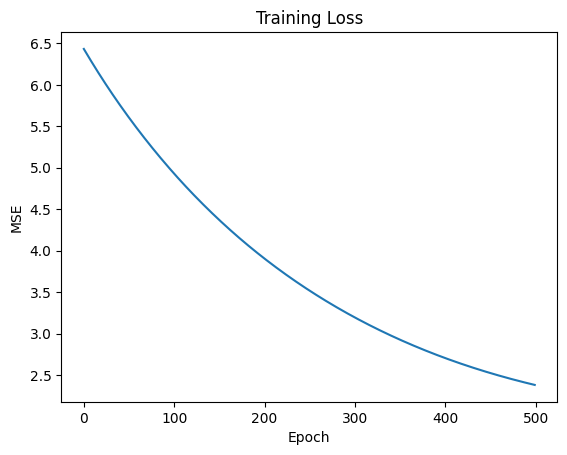

In [16]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

Cell 8 — True vs Predicted

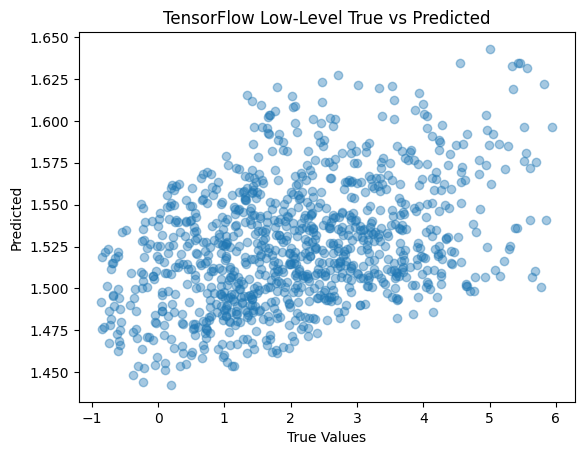

In [17]:
y_final = forward(X_tf).numpy()

plt.scatter(y, y_final, alpha=0.4)
plt.xlabel("True Values")
plt.ylabel("Predicted")
plt.title("TensorFlow Low-Level True vs Predicted")
plt.show()

Cell 9 — 4D Visualization (PCA)

We reduce 3D input to 2D and plot in 3D:

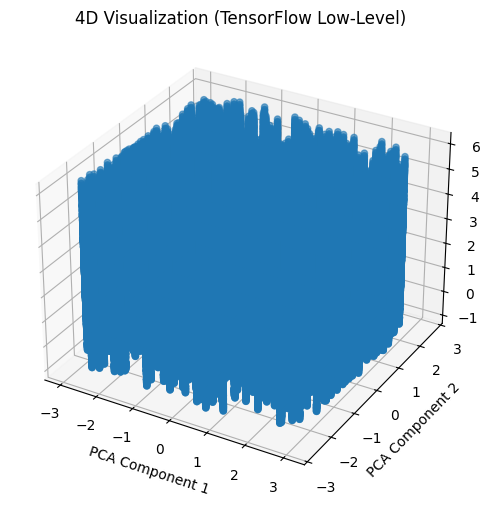

In [18]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_reduced[:,0], X_reduced[:,1], y, alpha=0.6)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("Output")
plt.title("4D Visualization (TensorFlow Low-Level)")
plt.show()